In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../processed_data/cmi_preprocessed.csv", index_col='id')
print(df.head())

    Basic_Demos-Age  Basic_Demos-Sex  CGAS-CGAS_Score  Physical-Height  \
id                                                                       
0               5.0                0             51.0       116.840000   
1               9.0                0             60.5       121.920000   
2              10.0                1             71.0       143.510000   
3               9.0                0             71.0       142.240000   
4              18.0                1             65.0       137.862733   

    Physical-Weight  Physical-HeartRate  BIA-BIA_Activity_Level_num  \
id                                                                    
0         23.042474           84.333333                         2.0   
1         20.865232           70.000000                         2.0   
2         34.291555           94.000000                         3.0   
3         37.013107           97.000000                         3.0   
4         34.926584           89.000000                

In [3]:
cols_to_keep = ["Basic_Demos-Age", "CGAS-CGAS_Score", "Physical-Height", "Physical-HeartRate", "BIA-BIA_BMI",
"BIA-BIA_DEE", "BIA-BIA_FFMI", "BIA-BIA_FMI", "Physical-Mean_arterial_pressure", "PAQ_Combined"]
df_outlier_detection = df[cols_to_keep]

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df_outlier_detection)

In [5]:
from pyod.models.loda import LODA
clf = LODA(contamination=0.01)
clf.fit(X)

,contamination,0.01
,n_bins,10
,n_random_cuts,100


In [6]:
outliers = clf.predict(X)
np.unique(outliers, return_counts=True)

(array([0, 1]), array([8176,   83]))

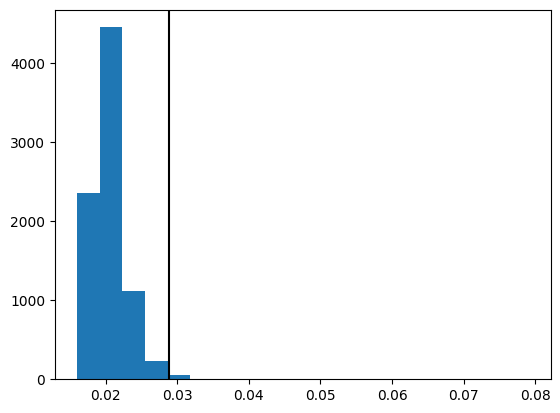

In [7]:
plt.hist(clf.decision_scores_, bins=20)
plt.axvline(np.min(clf.decision_scores_[np.where(outliers==1)]), c='k')
plt.show()

In [8]:
scores = clf.decision_scores_
labels = clf.labels_
df_outlier_detection['anomaly_score'] = scores
df_outlier_detection['is_outlier'] = labels
outliers = df_outlier_detection[df_outlier_detection['is_outlier'] == 1]
print(outliers)
df_outlier_detection.sort_values(by='anomaly_score', ascending=False).head(10)


      Basic_Demos-Age  CGAS-CGAS_Score  Physical-Height  Physical-HeartRate  \
id                                                                            
319               6.0        55.000000         110.4900                75.0   
350               5.0        60.000000         124.4600                94.0   
379              11.0        45.000000         147.3200               111.0   
436              19.0        39.000000         175.2600                69.0   
472              12.0        45.000000         165.1000               122.0   
...               ...              ...              ...                 ...   
7995             14.0        82.500000         177.0634                78.5   
8125             12.0        50.000000         181.4576                75.5   
8267             15.0        71.666667         168.3512                83.0   
8388             12.0        60.000000         178.0286                80.0   
8412             10.0        66.500000         155.2

,Basic_Demos-Age,CGAS-CGAS_Score,Physical-Height,Physical-HeartRate,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFMI,BIA-BIA_FMI,Physical-Mean_arterial_pressure,PAQ_Combined,anomaly_score,is_outlier
id,,,,,,,,,,,,
5615,13.0,55.5,166.9542,70.5,21.561823,80961.750842,15.292535,4.830934,80.666667,2.500000,0.079024,1
7404,17.0,70.0,178.4350,71.5,20.743664,1882.808061,206.601247,12.551978,89.166667,2.500000,0.067285,1
6675,12.0,57.5,152.8064,84.0,20.529972,1815.280474,204.435517,7.556359,95.333333,1.795000,0.064181,1
6273,16.0,49.0,177.3428,87.5,20.548077,124728.000000,17.574909,16.920504,119.666667,2.666667,0.062261,1
4996,8.0,67.0,184.3786,79.5,22.258700,2454.674282,169.322908,8.938762,95.833333,2.728333,0.054416,1
5448,10.0,71.5,152.3238,68.0,18.078301,124728.000000,14.142175,4.886692,76.166667,2.000000,0.049894,1
6763,12.0,77.5,173.7868,73.5,22.855530,59538.220877,16.836549,8.647894,74.166667,2.000000,0.048647,1
6010,5.0,59.0,143.1036,86.5,19.271938,46031.027969,16.325077,23.272336,80.000000,2.475000,0.047561,1
5221,14.0,62.5,159.3342,98.5,20.112471,53363.540487,16.283357,4.891628,77.166667,2.548333,0.047560,1


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# PCA (3 components for both 2D and 3D plots)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

ev = pca.explained_variance_ratio_
print(f"Explained variance — PC1: {ev[0]:.2%}, PC2: {ev[1]:.2%}")
print(f"Cumulative (2 PCs): {ev.sum():.2%}")

Explained variance — PC1: 25.66%, PC2: 7.18%
Cumulative (2 PCs): 32.84%


In [10]:
outlier_mask = labels == 1
n_outliers = outlier_mask.sum()

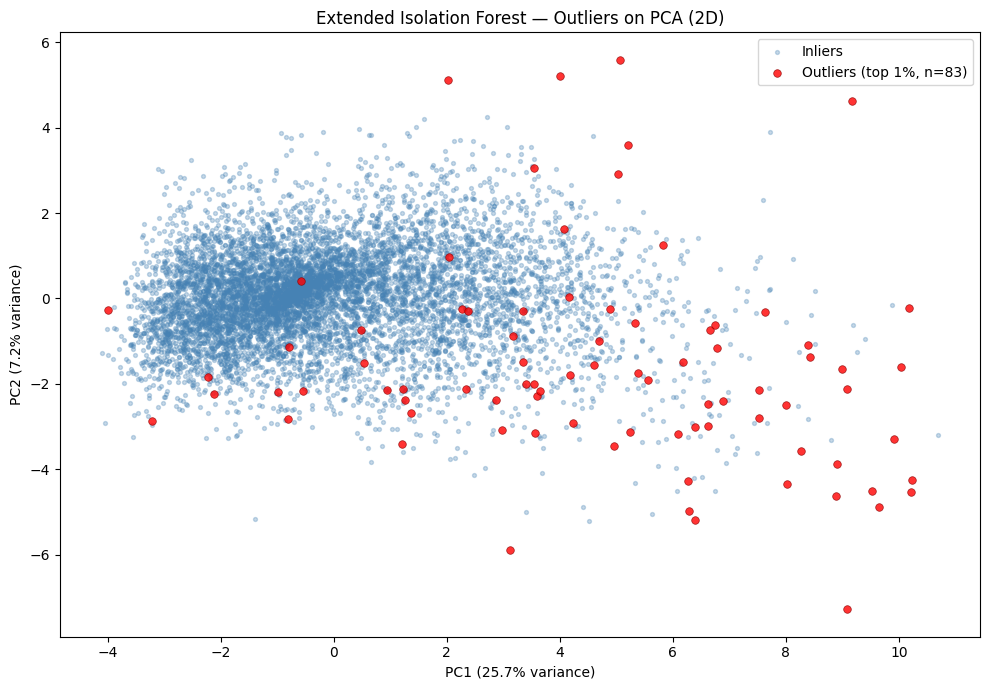

In [11]:
# 2D scatter plot (PC1 vs PC2)
fig, ax = plt.subplots(figsize=(10, 7))

inliers = ~outlier_mask
ax.scatter(X_pca[inliers, 0], X_pca[inliers, 1],
           c="steelblue", s=8, alpha=0.3, label="Inliers")
ax.scatter(X_pca[outlier_mask, 0], X_pca[outlier_mask, 1],
           c="red", s=30, alpha=0.8, edgecolors="darkred", linewidths=0.5,
           label=f"Outliers (top 1%, n={n_outliers})")

ax.set_xlabel(f"PC1 ({ev[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({ev[1]:.1%} variance)")
ax.set_title("Extended Isolation Forest — Outliers on PCA (2D)")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
df_outlier_detection.to_csv('../../outlier_data/loda.csv')